# Power performance of a WEC system
This notebook demonstrates solving the motion of a hydrodynamic system, calculating power, and evaluating the gradient of the system power with respect to PTO damping.

1. Define or ingest hydrodynamic coefficients
2. Define numerical simulation parameters and wave conditions
3. Define body mass properties, initial conditions, and PTO damping
4. Solve the system and calculate power
5. Gradient of power with respect to PTO damping

In [1]:
# First import all necessary julia packages:
using Unitful
using DimensionfulAngles: radᵃ as rad, θ₀, 𝐀, Dispersion
using LinearAlgebra
using Plots
import Random
# import NCDatasets
import NetCDF
import ForwardDiff as FD
import WaveSpectra

include("..\\src\\Hydrodynamics.jl")

Main.Hydrodynamics

First define the degrees of freedom for the system and the units that will be used.

Don't define force units with Newtons -- it will end up causing conflicts in the out-of-place ODE solves required by some AD packages


In [2]:
dof = 1:2:5
n_dof = length(dof)
dof_names = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"][dof]

length_units = u"m"
time_units = u"s"

mass_units = 1.0 .* [repeat([u"kg"], 3, 3) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) repeat([0u"kg*m^2"/rad], 3, 3)][dof,dof]

damping_units = 1.0 * [repeat([u"kg*m/s^2 / (m/s)"], 3, 3) repeat([u"kg*m/s^2 / (1/s)"/rad], 3, 3); repeat([u"kg*m/s^2 * m / (m/s)"], 3, 3) repeat([u"kg*m/s^2 * m / (1/s)"/rad], 3, 3)][dof,dof]
stiffness_units = 1.0 .* [repeat([u"kg*m/s^2 / m"], 3, 3) repeat([u"kg*m/s^2"/rad], 3, 3); repeat([u"kg*m/s^2 * m / m"], 3, 3) repeat([u"kg*m/s^2 * m"/rad], 3, 3)][dof,dof]
excitation_units = [repeat([u"kg*m/s^2 / m"], 3, 1); repeat([u"kg*m/s^2 * m / m"], 3, 1)][dof]

position_units = [u"m", u"m", u"m", rad, rad, rad]
velocity_units = position_units / time_units
acceleration_units = position_units / time_units^2


6-element Vector{Unitful.FreeUnits{N, D, nothing} where {N, D}}:
 m s^-2
 m s^-2
 m s^-2
 rad s^-2
 rad s^-2
 rad s^-2

In [3]:
# Hydrodynamics
bem_file = "data//rm3.nc"

A = NetCDF.ncread(bem_file, "added_mass")[dof, dof, :] .* mass_units # Dimensions: influenced_dof radiating_dof omega
B = NetCDF.ncread(bem_file, "radiation_damping")[dof, dof, :] .* damping_units # Dimensions: influenced_dof radiating_dof omega
Kₕₛ = NetCDF.ncread(bem_file, "hydrostatic_stiffness")[dof, dof]' .* stiffness_units # Dimensions: radiating_dof influenced_dof --> influenced_dof radiating_dof
fₑₓ = NetCDF.ncread(bem_file, "excitation_force")[dof, :, :, :] .* excitation_units # Dimensions: influenced_dof wave_dir omega complex

ω = NetCDF.ncread(bem_file, "omega")*rad/time_units
dω = ω[2] - ω[1]

f = uconvert.(time_units^-1, ω, Dispersion())
df = uconvert.(time_units^-1, dω, Dispersion())

# Hydrostatics parameters - these should also come from BEM
cg = [0., 0., -3.5]*u"m"
volume = 725.8330*u"m^3"
cb = [0.0, 0.0, -1.2927]*u"m"

3-element Vector{Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}:
  0.0 m
  0.0 m
 -1.2927 m

### Wave conditions and numerical set-up
Define relevant wave using WaveSpectra representations (including significant wave height, energy period, spectra, frequency dimension, etc) and time marching parameters (start, ramp, end times; time step)

In [4]:
# Wave conditions
Hₛ₀ = 1.0*length_units
Tₑ = 6.0*time_units

S = WaveSpectra.ParametricSpectra.spectrum_pierson_moskowitz(f, Hₛ₀, Tₑ)
ϕ = rand(Random.Xoshiro(0), Float64, size(S)) * 2 * pi * rad
maxS_index = argmax(S)

# Time-domain set-up
t0 = 0.0*time_units
tr = Tₑ * 1.0
tf = Tₑ * 10.0
dt = 1.0e-1*time_units
ts = collect(t0:dt:tf)
nt = length(ts)
i_ramp = Int64(tr / dt + 1)

elevation = sum(sqrt.(2*S*df) .* cos.(ω.*ts' .+ ϕ), dims=1)

1×601 Matrix{Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}:
 0.265498 m  0.281374 m  0.2966 m  …  0.141475 m  0.18647 m  0.228464 m

### Define body properties
The required body properties include center of gravity and center of buoyancy, mass, moments and products of inertia, displaced volume, and any initial displacements of the bodies.

PTO damping is lumped with radiation damping when the system of equations is solved, but it is defined as a separate input parameter so that it is a distinct input to power production and can be optimized accordingly.

In [5]:
# Body properties
m = 725833u"kg"
Ixx = [20907301, 21306090.66, 37085481.11]u"kg*m^2"/rad
Ixy = [1e6, 1e6, 1e5]u"kg*m^2"/rad
I = diagm(Ixx)
I[1, 2:3] = I[2:3, 1] = Ixy[1:2]
I[2, 3] = I[3, 2] = Ixy[3]
body_mass = [diagm(repeat([m], 3)) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) I]

# Coefficients for the form: ẍ + c * ẋ + k * x = 0
mass = body_mass[dof, dof] .+ A[:,: , maxS_index]
inv_mass_units = 1 ./ Unitful.unit.(mass')
inv_mass = inv(Unitful.ustrip.(mass)) .* inv_mass_units

g = zeros(6) .* acceleration_units
g[3] = -NetCDF.ncread(bem_file, "g")[1] * u"m/s^2"
force_gravity = diag(body_mass) .* g
rho = NetCDF.ncread(bem_file, "rho")[1] * u"kg/m^3"
force_buoyancy = - rho * g * volume
CGCB = cb - cg
force_buoyancy[4:6] = cross(CGCB, force_buoyancy[1:3])
force_hydrostatic = force_gravity[dof] + force_buoyancy[dof]

# Initial conditions
x₀ = zeros(size(dof)) .* position_units[dof]
dx₀ = zeros(size(dof)) .* velocity_units[dof]
u₀ = [x₀; dx₀]

# PTO parameters
kₚₜₒ = diagm(zeros(size(dof))) .* stiffness_units
cₚₜₒ = diagm(1.0e5 .* ones(size(dof))) .* damping_units
pto = (x₀, kₚₜₒ, cₚₜₒ)

# Mooring parameters
kₘ = diagm(zeros(size(dof))) .* stiffness_units
cₘ = diagm(zeros(size(dof))) .* damping_units
mooring = (x₀, kₘ, cₘ)

(Quantity{Float64}[0.0 m, 0.0 m, 0.0 rad], Quantity{Float64}[0.0 kg s^-2 0.0 kg s^-2 0.0 kg m rad^-1 s^-2; 0.0 kg s^-2 0.0 kg s^-2 0.0 kg m rad^-1 s^-2; 0.0 kg m s^-2 0.0 kg m s^-2 0.0 kg m^2 rad^-1 s^-2], Quantity{Float64}[0.0 kg s^-1 0.0 kg s^-1 0.0 kg m rad^-1 s^-1; 0.0 kg s^-1 0.0 kg s^-1 0.0 kg m rad^-1 s^-1; 0.0 kg m s^-1 0.0 kg m s^-1 0.0 kg m^2 rad^-1 s^-1])

### Convolution integral and state space forms of the radiation damping
The radiation damping can also be represented by a convolution integral of the radiation impulse response function and the velocity history. This integral is commonly represented in a state space form to decrease computational expense of the simulation.

Note that this form uses the infinite frequency added mass, which requires recalculating the total mass matrix of the system and its inverse.

In [6]:
# Convolution integral calculation
include("..\\src\\Hydrodynamics.jl")
Kᵣ, tᵣ = Hydrodynamics.Bemio.radiation_irf(Unitful.ustrip.(B), Unitful.ustrip.(ω), w_max = 5.0, t=collect(0:0.1:30)')
tᵣ = tᵣ .* u"s"
Kᵣ = Kᵣ .* damping_units .* u"s^-1"
Ainf = A[:,:,end]
# Ainf = Hydrodynamics.Bemio.alternate_Ainf(Unitful.ustrip.(Kᵣ), hydro.am, hydro.w, Unitful.ustrip.(tᵣ)) .* mass_units
cic = (Unitful.ustrip.(Kᵣ), Unitful.ustrip.(tᵣ))

# State space formation
Aᵣ, Bᵣ, Cᵣ, Dᵣ, Kₛₛ, R²ₛₛ, orderₛₛ = Hydrodynamics.Bemio.radiation_state_space(Kᵣ, tᵣ, 8, 0.95)
nₛₛ = sum(orderₛₛ)
s₀ = zeros(nₛₛ)
ss = (Aᵣ, Bᵣ, Cᵣ, Dᵣ, nₛₛ)
u₀_ss = [x₀; dx₀; s₀]

# Adjusted mass calculations
mass_inf = body_mass[dof,dof] .+ Ainf
inv_mass_inf = inv(Unitful.ustrip.(mass_inf)) .* inv_mass_units

dof: 1 1; order: 4
dof: 1 2; order: 4
dof: 1 3; order: 4
dof: 2 1; order: 8
dof: 2 2; order: 2
dof: 2 3; order: 4
dof: 3 1; order: 2
dof: 3 2; order: 8
dof: 3 3; order: 2


3×3 Matrix{Quantity{Float64}}:
  1.26837e-6 kg^-1    1.07833e-21 kg^-1   -0.0 kg^-1 m^-1
 -5.65532e-23 kg^-1   5.08289e-7 kg^-1    -0.0 kg^-1 m^-1
  0.0 rad kg^-1 m^-1  0.0 rad kg^-1 m^-1   4.69349e-8 rad kg^-1 m^-2

### System parameter formatting and energy functions 
All parameters for the system are stored in the tuple `p` to be input to the relevation hydrodynamic and power calculation functions.

In [7]:
# Unitful and unitless parameter groups
wave = (ω, ϕ, S, df, t0, tr)
hydro =  (Kₕₛ, B[:,:,maxS_index], fₑₓ, force_hydrostatic, wave) # optionally cic or ss tuples on the end
p_unitful = (inv_mass, hydro, pto, mooring)

wave_unitless = (Unitful.ustrip.(ω), Unitful.ustrip.(ϕ), Unitful.ustrip.(S), Unitful.ustrip.(df), Unitful.ustrip.(t0), Unitful.ustrip.(tr))
hydro_unitless = Unitful.ustrip.(Kₕₛ), Unitful.ustrip.(B[:,:,maxS_index]), Unitful.ustrip.(fₑₓ), Unitful.ustrip.(force_hydrostatic), wave_unitless
p_unitless = (Unitful.ustrip.(inv_mass), 
              hydro_unitless, 
              (Unitful.ustrip.(x₀), Unitful.ustrip.(kₚₜₒ), Unitful.ustrip.(cₚₜₒ)), 
              (Unitful.ustrip.(x₀), Unitful.ustrip.(kₘ), Unitful.ustrip.(cₘ)))

# CIC specific parameter set
hydro_unitless_cic = Unitful.ustrip.(Kₕₛ), Unitful.ustrip.(B[:,:,maxS_index]), Unitful.ustrip.(fₑₓ), Unitful.ustrip.(force_hydrostatic), wave_unitless, cic
p_unitless_cic = (Unitful.ustrip.(inv_mass_inf), 
                  hydro_unitless_cic, 
                  (Unitful.ustrip.(x₀), Unitful.ustrip.(kₚₜₒ), Unitful.ustrip.(cₚₜₒ)), 
                  (Unitful.ustrip.(x₀), Unitful.ustrip.(kₘ), Unitful.ustrip.(cₘ)))

# SS specific parameter set
hydro_unitless_ss = Unitful.ustrip.(Kₕₛ), Unitful.ustrip.(B[:,:,maxS_index]), Unitful.ustrip.(fₑₓ), Unitful.ustrip.(force_hydrostatic), wave_unitless, ss
p_unitless_ss = (Unitful.ustrip.(inv_mass_inf), 
                 hydro_unitless_ss, 
                 (Unitful.ustrip.(x₀), Unitful.ustrip.(kₚₜₒ), Unitful.ustrip.(cₚₜₒ)), 
                 (Unitful.ustrip.(x₀), Unitful.ustrip.(kₘ), Unitful.ustrip.(cₘ)))

([1.2683677774844085e-6 1.0783267921268098e-21 -0.0; -5.655317474796333e-23 5.082890062841699e-7 -0.0; 0.0 0.0 4.693493592784703e-8], ([0.0 0.0 0.0; 0.0 2.8009728217349667e6 1.1152678780490533e-9; 0.0 1.1152678780490533e-9 7.206113481356028e7], [135344.33001670157 -2.9383674980356134e-10 904537.5106024488; -2.4486395816963446e-11 651958.17526471 -2.0288727962626855e-10; 1.0270659743354523e6 -4.792337467034275e-10 6.862311041965676e6], [2.0311041737386404e-8; 2.8001482923547793e6; 2.1285016593708406e-7;;; 5.179072573469057e-6; 2.797665062134365e6; 5.425501727529536e-5;;; 0.00013186801719200503; 2.793499390076672e6; 0.0013805005377349744;;; … ;;; 2961.423416463907; 609.279939604098; -116.27806247850049;;; -2730.4245875278366; 568.9036671246315; -1950.879191356708;;; -8358.99855510351; 555.4191684153839; -3663.187884503496;;;; -375.2554181510859; -0.3394843812692425; -3932.7180457749105;;; -1500.7369278289316; -5.411167118690884; -15721.822910428762;;; -3375.588449860431; -27.224832625149

## Solve and visualize the system response
Solve the system for the given inputs and visualize its response.

In [8]:
# Solve the hydrodynamic system
solution_point = Hydrodynamics.hydrodynamic_solver(Unitful.ustrip.(u₀), Unitful.ustrip.(ts), p_unitless, method=:point)
solution_cic = Hydrodynamics.hydrodynamic_solver(Unitful.ustrip.(u₀), Unitful.ustrip.(ts), p_unitless_cic, method=:cic)
solution_ss = Hydrodynamics.hydrodynamic_solver(Unitful.ustrip.(u₀_ss), Unitful.ustrip.(ts), p_unitless_ss, method=:ss)

retcode: Success
Interpolation: 1st order linear
t: 601-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  ⋮
 59.2
 59.3
 59.4
 59.5
 59.6
 59.7
 59.8
 59.9
 60.0
u: 601-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [-1.0869098604209545e-7, 2.5025755354860522e-8, -2.796537270290178e-8, -4.229640681056381e-6, 1.0681081641885999e-6, -1.0885041135736188e-6, 2.1390558409517218e-5, -4.8996079586316245e-8, 7.216476873957524e-6, -6.234767926785614e-6  …  -3.1302317293476987e-12, -8.699203806248171e-14, -2.704026101033561e-13, 8.693906846161821e-13, -1.0871783380585647e-12, 8.375679744126575e-13, -1.4892235938998536e-13, 4.4860489640677834e-13, 8.825035834630492e-7, -2.4692649450120144e-5]
 [-1.5466425190376476e-6, 5.058833528316363e-7, -3.9813542949882133e-7, -2.897622572023451e-5, 1.1152231393601536e-5, -7.459384610090376e-6, 0.0002979779926835733, -1.2143427055307

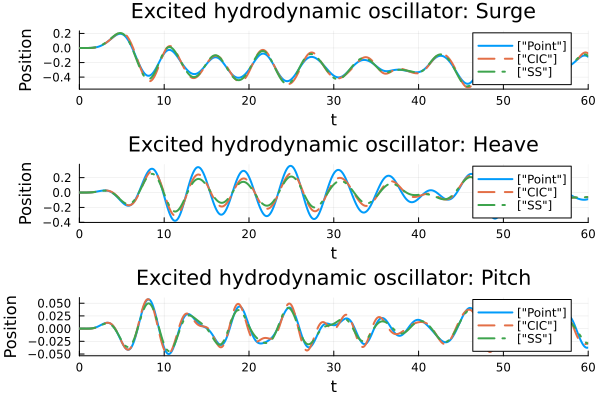

In [9]:
# Visualize response
p1 = Plots.plot(solution_point, idxs = [1], label = ["Point"], title = "Excited hydrodynamic oscillator: Surge", xaxis="Time", yaxis = "Position", lw = 2,)
p1 = Plots.plot!(solution_cic, idxs = [1], label = ["CIC"], lw = 2, ls=:dash)
p1 = Plots.plot!(solution_ss, idxs = [1], label = ["SS"], lw = 2, ls=:dashdot)

p2 = Plots.plot(solution_point, idxs = [2], label = ["Point"], title = "Excited hydrodynamic oscillator: Heave", xaxis="Time", yaxis = "Position", lw = 2,)
p2 = Plots.plot!(solution_cic, idxs = [2], label = ["CIC"], lw = 2, ls=:dash)
p2 = Plots.plot!(solution_ss, idxs = [2], label = ["SS"], lw = 2, ls=:dashdot)

p3 = Plots.plot(solution_point, idxs = [3], label = ["Point"], title = "Excited hydrodynamic oscillator: Pitch", xaxis="Time", yaxis = "Position", lw = 2,)
p3 = Plots.plot!(solution_cic, idxs = [3], label = ["CIC"], lw = 2, ls=:dash)
p3 = Plots.plot!(solution_ss, idxs = [3], label = ["SS"], lw = 2, ls=:dashdot)

Plots.plot(p1, p2, p3, layout=(3,1))


## Power performance
Finally, utilize the power or loss functions to calculate performance of the system and assess the gradient with respect to power.

ForwardDifference currently does not work with units. It will create zero / empty arrays of the input type (`Unitful Vector{Quantity{Float}}`) during the calculation which is too ambiguous to solve with.

Note that the differentiated functions must accept one and only one input (the quantity that the function output is differentiated against). If the energy or loss functions take both the AD input and the parameter set `p`, then they must be redefined as 1-argument anonymous functions:
```julia
gradient_fd = FD.gradient((cpto)->power_performance(cpto, p), pto_damping_ul)
gradient_loss_fd = FD.gradient((cpto)->power_loss(cpto, p), pto_damping_ul)
```

Note that there is no jacobian call because there is only a scalar output here (mean energy). There is no derivative call because the input (pto_damping) is not a scalar. For 1 DOF systems, keep pto_damping is a 1x1 vector to allow the use of gradient in both cases.

In [10]:
# Calculation of power and loss
function power_performance(pto_damping, p)
    (p2, u₀, ts, dt, i_ramp, method) = p

    # Unwrap, edit and rewrap `p2` to combine pto and radiation damping. 
    # p2[2] .= p2[2] .+ pto_damping # Don't do this - it overwrites the base p value, skewing iterative calls to power_performance
    (inv_mass, hydro, pto, mooring) = p2
    x₀, kₚₜₒ, cₚₜₒ = pto
    cₚₜₒ = pto_damping
    pto = x₀, kₚₜₒ, cₚₜₒ
    p2 = (inv_mass, hydro, pto, mooring)
    
    diff_eq_solution = Hydrodynamics.hydrodynamic_solver(u₀, ts, p2; method=method)

    # only absorb power in heave
    heave_ind = findall(x->x==3, Vector(dof))[1]
    heave_damping = pto_damping[heave_ind, heave_ind]
    heave_vel = diff_eq_solution[heave_ind,:]
    power = heave_vel .^ 2 .* heave_damping
    energy = sum(power[i_ramp:end]) * dt
    return energy
end

function power_performance(pto_damping)
    power_performance(pto_damping, (p, Unitful.ustrip.(u₀), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method))
end

function power_performance_ss(pto_damping)
    power_performance(pto_damping, (p, Unitful.ustrip.(u₀_ss), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method))
end

function power_loss(pto_damping, p)
    # Note p /must/ be passed into power_performance. 
    # If not passed, power_performance uses the global 'p' instead of the 'p' redefined within this function call (counterintuitive yes) 
    - power_performance(pto_damping, p)
end

function power_loss(pto_damping)
    - power_performance(pto_damping)
end

power_loss (generic function with 2 methods)

In [11]:
### Point frequency method - energy and gradient
### Calculate energy 
p = p_unitless
method = :point
energy = power_performance(Unitful.ustrip.(cₚₜₒ)) # lump appropriate unitful/unitless u₀, ts, dt into the power_performance parameter set, p 
loss = power_loss(Unitful.ustrip.(cₚₜₒ), (p_unitless, Unitful.ustrip.(u₀), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method))
[energy, loss]

### Calculate gradient of energy with respect to PTO damping 
# PTO_damping is not a scalar input here so there is no derivative call.
# derivative_fd = FD.derivative(power_performance, Unitful.ustrip.(cₚₜₒ)[1,1])

# Use gradient for multiple dofs. Also works with a single dof if pto_damping is a 1x1 array
gradient_fd = FD.gradient(power_performance, Unitful.ustrip.(cₚₜₒ))
gradient_loss_fd = FD.gradient(power_loss, Unitful.ustrip.(cₚₜₒ))


3×3 Matrix{Float64}:
 -9.2464e-18    1.22456e-17   1.92049e-18
 -0.134576     -1.596         0.0326211
  4.85242e-18  -1.07585e-17  -1.169e-18

In [12]:
### CIC method - energy and gradient
### Calculate energy 
p = p_unitless_cic
method = :cic
energy = power_performance(Unitful.ustrip.(cₚₜₒ)) # lump appropriate unitful/unitless u₀, ts, dt into the power_performance parameter set, p 
loss = power_loss(Unitful.ustrip.(cₚₜₒ), (p, Unitful.ustrip.(u₀), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method))
[energy, loss]

### Calculate gradient of energy with respect to PTO damping 
# PTO_damping is not a scalar input here so there is no derivative call.
# derivative_fd = FD.derivative(power_performance, Unitful.ustrip.(cₚₜₒ)[1,1])

# Use gradient for multiple dofs. Also works with a single dof if pto_damping is a 1x1 array
gradient_fd = FD.gradient(power_performance, Unitful.ustrip.(cₚₜₒ))
# gradient_loss_fd = FD.gradient(power_loss, Unitful.ustrip.(cₚₜₒ))

MethodError: MethodError: no method matching Float64(::ForwardDiff.Dual{ForwardDiff.Tag{typeof(power_performance), Float64}, Float64, 9})
The type `Float64` exists, but no method is defined for this combination of argument types when trying to construct it.

Closest candidates are:
  (::Type{T})(::Real, !Matched::RoundingMode) where T<:AbstractFloat
   @ Base rounding.jl:265
  (::Type{T})(::T) where T<:Number
   @ Core boot.jl:965
  Float64(!Matched::Irrational{:SQRT_HALF})
   @ Random irrationals.jl:271
  ...


In [13]:
### SS method - energy and gradient
### Calculate energy 
p = p_unitless_ss
method = :ss
energy = power_performance(Unitful.ustrip.(cₚₜₒ), (p, Unitful.ustrip.(u₀_ss), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method)) # lump appropriate unitful/unitless u₀, ts, dt into the power_performance parameter set, p 
loss = power_loss(Unitful.ustrip.(cₚₜₒ), (p, Unitful.ustrip.(u₀_ss), Unitful.ustrip.(ts), Unitful.ustrip.(dt), i_ramp, method))
[energy, loss]

### Calculate gradient of energy with respect to PTO damping 
# PTO_damping is not a scalar input here so there is no derivative call.
# derivative_fd = FD.derivative(power_performance, Unitful.ustrip.(cₚₜₒ)[1,1])

# Use gradient for multiple dofs. Also works with a single dof if pto_damping is a 1x1 array
gradient_fd = FD.gradient(power_performance_ss, Unitful.ustrip.(cₚₜₒ))
# gradient_loss_fd = FD.gradient(power_loss, Unitful.ustrip.(cₚₜₒ))

3×3 Matrix{Float64}:
 -6.31137e-17  -1.58788e-17   8.86257e-18
  0.0610609     0.686214     -0.0108873
  7.89586e-17  -7.21517e-17  -1.56517e-17